In [ ]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = D:\Resonance\TEP_analysis


In [2]:
# === imports ===
import pandas as pd 
import numpy as np 
from h5py import File
import json
import os 

# graphics
import matplotlib.pyplot as plt 
import seaborn as sns
from mne.viz import plot_topomap
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

In [70]:
from src.utils.montage_processing import *
filename_colors = r"../resources/channel_colors.json"
with open(filename_colors, "r") as f:
    EEG64_REGION_COLOR = json.load(f)
CED_FILE = r"../resources/mks64_standard.ced"
df = pd.read_csv(CED_FILE, sep='\t')
df["colors"] = df["labels"].map(EEG64_REGION_COLOR)
colors = df["colors"].values

In [ ]:
import h5py
import os
folder = r"D:\2025 - TEP\data - trans\CLEAN_EPOCHS_UI"
filenames = os.listdir(folder)
filenames = np.asarray([filename for filename in filenames if filename.find("SOUND.mat") != -1])
session_dict = {
    "01AV": 38, 
    "04KK": 39, 
    "02NS": 41, 
    "03AZ": 40, 
    "07IK": 42, 
    "05UB": 43, 
    "08EN": 45, 
    "10ES": 52
}
def get_session_n(filename):
    return int(filename[filename.find("_")+1: filename.find("__")])
filenames = np.asarray([filename for filename in filenames if get_session_n(filename) in session_dict.values()])
print(session_dict.values())
print(filenames)


dict_values([38, 39, 41, 40, 42, 43, 45, 52])
['session_38__set_1__cleaned_SOUND.mat'
 'session_38__set_2__cleaned_SOUND.mat'
 'session_38__set_3__cleaned_SOUND.mat'
 'session_38__set_4__cleaned_SOUND.mat'
 'session_38__set_5__cleaned_SOUND.mat'
 'session_38__set_6__cleaned_SOUND.mat'
 'session_38__set_7__cleaned_SOUND.mat'
 'session_38__set_8__cleaned_SOUND.mat'
 'session_38__set_9__cleaned_SOUND.mat'
 'session_39__set_10__cleaned_SOUND.mat'
 'session_39__set_1__cleaned_SOUND.mat'
 'session_39__set_2__cleaned_SOUND.mat'
 'session_39__set_3__cleaned_SOUND.mat'
 'session_39__set_4__cleaned_SOUND.mat'
 'session_39__set_5__cleaned_SOUND.mat'
 'session_39__set_6__cleaned_SOUND.mat'
 'session_39__set_7__cleaned_SOUND.mat'
 'session_39__set_8__cleaned_SOUND.mat'
 'session_39__set_9__cleaned_SOUND.mat'
 'session_40__set_1__cleaned_SOUND.mat'
 'session_40__set_2__cleaned_SOUND.mat'
 'session_40__set_3__cleaned_SOUND.mat'
 'session_40__set_4__cleaned_SOUND.mat'
 'session_40__set_5__cleaned_SOUN

In [12]:
def decode_matlab_string_payload(ds):
    arr = np.asarray(ds[()]).ravel().astype(np.uint64)

    ndims = int(arr[1])
    shape = tuple(int(x) for x in arr[2:2 + ndims])
    n_items = int(np.prod(shape))

    lengths_start = 2 + ndims
    lengths = [int(x) for x in arr[lengths_start:lengths_start + n_items]]
    packed = arr[lengths_start + n_items:]

    codes = []
    for value in packed:
        codes.extend(
            np.frombuffer(int(value).to_bytes(8, "little"), dtype="<u2").tolist()
        )

    strings = []
    pos = 0
    for length in lengths:
        strings.append("".join(chr(c) for c in codes[pos:pos + length]))
        pos += length

    return np.array(strings, dtype=object).reshape(shape, order="F")

def read_matlab_string(f, dataset_path):
    desc = np.asarray(f[dataset_path][()]).ravel()
    mcos_index = int(desc[4]) + 1
    ref = f["#subsystem#/MCOS"][()].ravel()[mcos_index]
    return decode_matlab_string_payload(f[ref])


In [24]:
def get_orig_name(fn):
    with h5py.File(fn, "r") as hdf:
        orig = read_matlab_string(hdf, "cleanedResult/sourceDatasets/OriginalFile")
        orig = orig.ravel(order="F").tolist()
        return orig[0]

fl_dict = {}
for filename in filenames:
    fl_dict[str(filename)] = get_orig_name(os.path.join(folder, filename))
fl_dict

{'session_38__set_1__cleaned_SOUND.mat': '01_01AV_M1_PA_39MSO_real.hdf5',
 'session_38__set_2__cleaned_SOUND.mat': '02_01AV_M1_PA_39MSO_MI.hdf5',
 'session_38__set_3__cleaned_SOUND.mat': '03_01AV_M1_AP_43MSO_real.h5',
 'session_38__set_4__cleaned_SOUND.mat': '04_01AV_M1_AP_43MSO_MI.hdf5',
 'session_38__set_5__cleaned_SOUND.mat': '05_01AV_M1_PA_39MSO_real.hdf5',
 'session_38__set_6__cleaned_SOUND.mat': '06_01AV_M1_PA_39MSO_MI.hdf5',
 'session_38__set_7__cleaned_SOUND.mat': '07_01AV_M1_AP_43MSO_real.hdf5',
 'session_38__set_8__cleaned_SOUND.mat': '08_01AV_M1_AP_43MSO_MI.hdf5',
 'session_38__set_9__cleaned_SOUND.mat': '09_01AV_PPC_L_54MSO_real.hdf5',
 'session_39__set_10__cleaned_SOUND.mat': 'rest01_04KK_M1_PA_31MSO.hdf5',
 'session_39__set_1__cleaned_SOUND.mat': '01_04KK_M1_PA_32MSO_real.hdf5',
 'session_39__set_2__cleaned_SOUND.mat': '02_04KK_M1_PA_32MSO_MI.hdf5',
 'session_39__set_3__cleaned_SOUND.mat': '03_04KK_M1_AP_50MSO_real.hdf5',
 'session_39__set_4__cleaned_SOUND.mat': '04_04KK_

In [66]:
fn = os.path.join(folder, filenames[0])
def code_labels(labels, n):
    lab = np.zeros((n, 3))
    lab[np.where(labels == "animatedSingle1500_tms_+200ms_nosounds_bar.mkv"), 0] = 1
    lab[np.where(labels == "animatedSingle1500_tms_0ms_nosounds_bar.mkv"), 1] = 1
    lab[np.where(labels == "rest1500_tms_0ms_bar.mkv"), 2] = 1  
    return lab  

def get_data(fn):
    with h5py.File(fn, "r") as hdf:
        tvec = hdf['cleanedResult/tvec'][:][0]
        epoch  = hdf['cleanedResult/epochs_clean'][:] 
        
        label = read_matlab_string(hdf, "cleanedResult/epoch_types")
        label = label.ravel(order="F").tolist()
        labels = np.asarray([json.loads(stimulus)["stimulus"] for stimulus in label])
        lab = code_labels(labels, epoch.shape[1])

        orig = read_matlab_string(hdf, "cleanedResult/sourceDatasets/OriginalFile")
        orig = orig.ravel(order="F").tolist()
        return tvec, epoch, lab

In [69]:
subj = "01AV" 
cond = "real" 
spot = "M1_PA"

def get_epochs(subj, cond, spot, filenames):
    session_id = session_dict[subj] 
    epochs = []
    labels = []
    for filename in [fn for fn in filenames if fn.find(str(session_id)) != -1]:
        orig = get_orig_name(os.path.join(folder, filename))
        if orig.find(cond) != -1 and orig.find(spot) != -1:
            print("---", orig, "---", filename, "---")
            tvec, epoch, lab = get_data(os.path.join(folder, filename))
            epochs.append(epoch)
            labels.extend(lab)
    epochs = np.concat(epochs, axis=1)
    labels = np.asarray(labels)
    return epochs, labels, tvec

epochs, labels, tvec  = get_epochs(subj, cond, spot, filenames)
epochs.shape, labels.shape

--- 01_01AV_M1_PA_39MSO_real.hdf5 --- session_38__set_1__cleaned_SOUND.mat ---
--- 05_01AV_M1_PA_39MSO_real.hdf5 --- session_38__set_5__cleaned_SOUND.mat ---


((64, 150, 4001), (150, 3))

In [68]:
rest_mask = np.where(labels[:, 2] == 1)[0]
onset_mask = np.where(labels[:, 1] == 1)[0]
after_mask = np.where(labels[:, 0] == 1)[0]

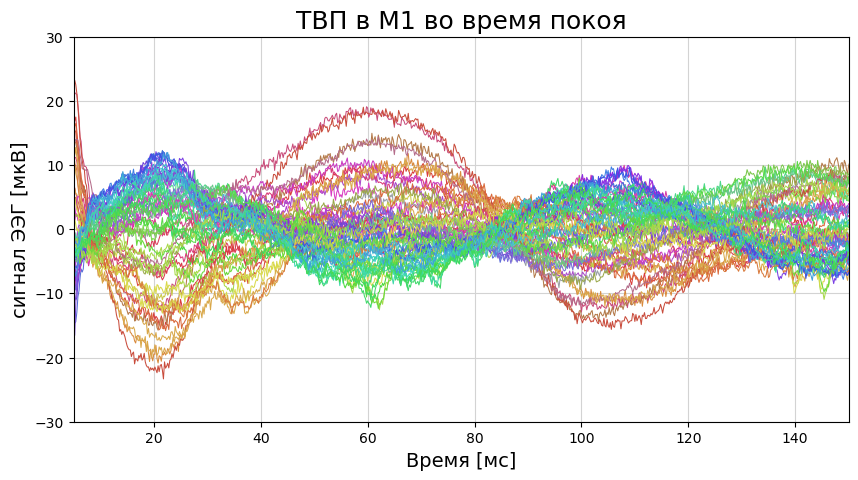

In [ ]:
tmin, tmax = 5, 150
amp = 30

n20 = (10, 25)
p30 = (20, 40)
n45 = (40, 55)
p60 = (55, 75)
n100 = (80, 140)
comps = [n20, p30, n45, p60, n100]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

TEPs = np.mean(epochs[:, rest_mask, :], axis=1)
for color, TEP in zip(colors, TEPs): # начало движения
    ax.plot(tvec, TEP, color=color, linewidth=.75)
ax.set_xlim(tmin, tmax)
ax.set_ylim(-amp, amp)
ax.set_xlabel("Время [мс]", fontsize=14)
ax.set_ylabel("сигнал ЭЭГ [мкВ]", fontsize=14)
ax.grid(color="lightgrey")



ax.set_title('ТВП в М1 во время покоя', fontsize=18)

ax.axvline(0, color="black", linewidth=2)

In [95]:
n20 = (10, 25)
p30 = (20, 40)
n45 = (40, 55)
p60 = (55, 75)
n100 = (80, 140)
comps = [n20, p30, n45, p60, n100]
funs = [np.min, np.max, np.min, np.max, np.min]
n_mean = 3
cond_names = ["rest", "onset", "after"]
comp_names = ["n20", "p30", "n45", "p60", "n100"]
df = []
for cond_mask, cond_name in zip([rest_mask, onset_mask, after_mask], cond_names):
    TEPs = np.mean(epochs[:, cond_mask, :], axis=1)
    for comp, fun, comp_name in zip(comps, funs , comp_names):
        time_mask = np.where((tvec>=comp[0]) & (tvec <=comp[1]))
        TEP = TEPs[:, time_mask]
        amp = fun(TEP, axis=0)
        amp_abs = np.mean(np.sort(np.abs(amp))[0][-n_mean:])
        df.append({
            "cond": cond_name, 
            "comp": comp_name, 
            "amp": round(amp_abs, 2)
        })

In [94]:
pd.DataFrame(df)

,cond,comp,ammp
0,rest,n20,22.629999
1,rest,p30,12.150000
2,rest,n45,10.800000
3,rest,p60,19.010000
4,rest,n100,15.480000
5,onset,n20,11.130000
6,onset,p30,11.000000
7,onset,n45,9.770000
8,onset,p60,13.720000
9,onset,n100,9.390000


In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
filename = r"C:\Users\hodor\Documents\lab-MSU\Works\Конференции\Физиологическая им Павлова 2026\results.xlsx"
df_all= pd.read_excel(filename)

In [35]:
filename = r"..\..\results\pavlov2026\tables\pavlov2026_14AL_amplitudes_summary.csv"
df_14AL= pd.read_csv(filename)
filename = r"..\..\results\pavlov2026\tables\pavlov2026_09TI_amplitudes_summary.csv"
df_09TI = pd.read_csv(filename)

df_all = pd.concat([df_all, df_09TI, df_14AL], ignore_index=True)

In [36]:
df = df_all.loc[(df_all.spot != "PPC_L") & (df_all.condition != "after")]

In [94]:
import copy
df_comp = []
for subject in df.subject.unique():
    for component in df.component.unique():
        df_cur = df.loc[(df.subject == subject) & (df.component == component)]
        for spot in df_cur.spot.unique():
            df_curr = df_cur.loc[df_cur.spot==spot]
            comp = {
                "subject": subject, 
                "comp": component, 
                "spot": spot
            }
            for cond in ["real", "MI"]:
                comp_real = copy.copy(comp)
                comp_real["amp"] =   df_curr.loc[(df_curr.run_cond == cond) & (df_curr.condition == "onset")]["amplitude_signed_mean_topn_uv"].values[0].round(2)
                comp_real["lat"] =   df_curr.loc[(df_curr.run_cond == cond) & (df_curr.condition == "onset")]["latency_mean_topn_ms"].values[0].round(2)
                comp_real["condition"] = cond
                df_comp.append(comp_real)
            comp_real = copy.copy(comp)
            comp_real["amp"] =   round(df_curr.loc[df_curr.condition == "rest"]["amplitude_signed_mean_topn_uv"].mean(), 2)
            comp_real["lat"] =   round(df_curr.loc[df_curr.condition == "rest"]["latency_mean_topn_ms"].mean(), 2)
            comp_real["condition"] = "rest"
            df_comp.append(comp_real)

df_comp = pd.DataFrame(df_comp)
df_comp

,subject,comp,spot,amp,lat,condition
0,01AV,n20,M1_PA,-10.24,18.27,real
1,01AV,n20,M1_PA,-13.94,17.80,MI
2,01AV,n20,M1_PA,-18.76,20.93,rest
3,01AV,n20,M1_AP,-4.83,15.80,real
4,01AV,n20,M1_AP,-7.76,15.60,MI
...,...,...,...,...,...,...
280,14AL,n100,M1_PA,-5.01,102.73,MI
281,14AL,n100,M1_PA,-6.75,100.73,rest
282,14AL,n100,M1_AP,-5.12,118.20,real
283,14AL,n100,M1_AP,-6.75,100.13,MI


In [101]:
fl = r"..\..\results\pavlov2026\short_table.xlsx"
df_comp.to_excel(fl, index=False)

In [122]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
fl = r"..\..\results\pavlov2026\short_table.xlsx"
df_comp= pd.read_excel(fl, engine="openpyxl")

Text(0.5, 1.0, 'AP')

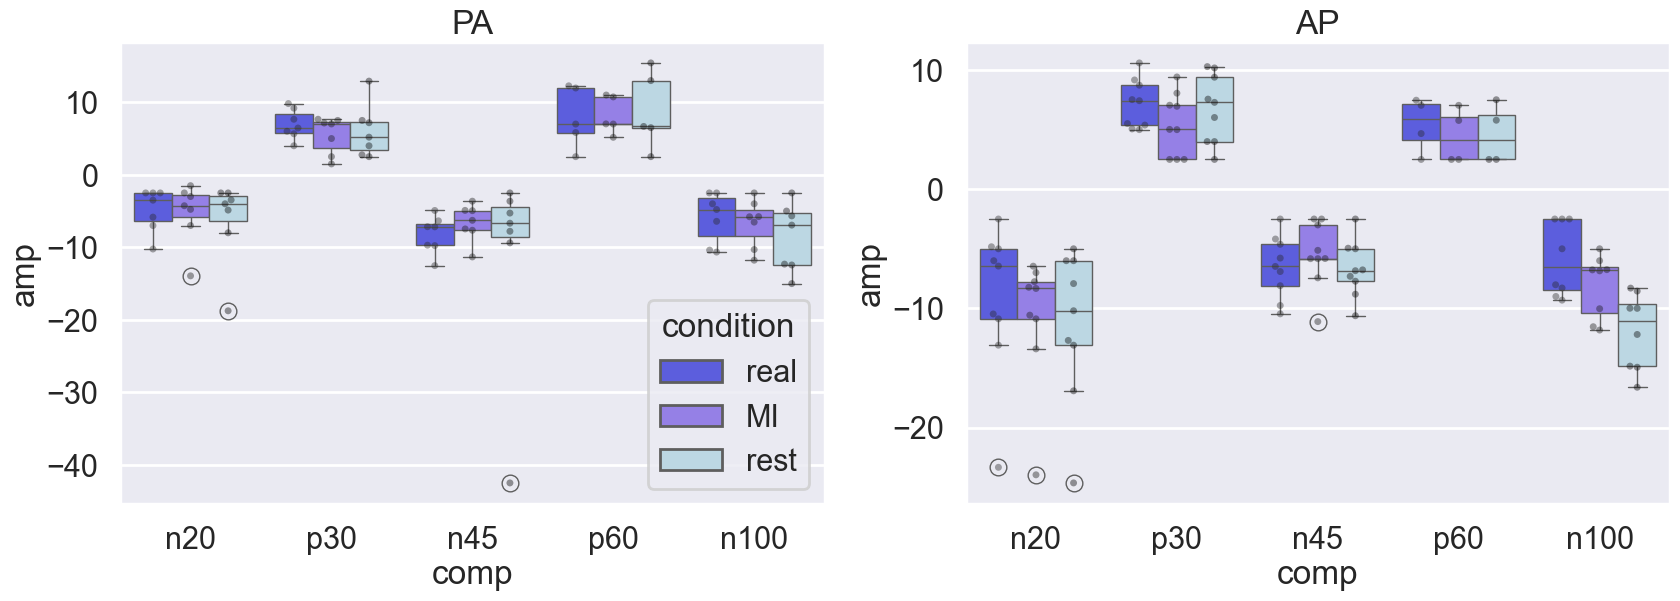

In [128]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
palette = {
    "rest": "#B6DAE9",   # голубой
    "MI":   "#8B6FF7",   # фиолетовый
    "real": "#4649F3"    # красный
}

sns.set_theme("poster")
sns.boxplot(df_comp.loc[df_comp.spot == "M1_PA"], x="comp", y="amp", hue="condition", palette=palette, ax=ax[0])
sns.swarmplot(df_comp.loc[df_comp.spot == "M1_PA"], x="comp", y="amp", hue="condition", ax=ax[0], dodge=True, palette='dark:black', alpha=.4, legend=False)
sns.boxplot(df_comp.loc[df_comp.spot == "M1_AP"], x="comp", y="amp", hue="condition", palette=palette,ax=ax[1], legend=False)
sns.swarmplot(df_comp.loc[df_comp.spot == "M1_AP"], x="comp", y="amp", hue="condition", ax=ax[1], dodge=True, palette='dark:black', alpha=.4, legend=False)


ax[0].set_title("PA")
ax[1].set_title("AP")

In [113]:
 df_comp.subject.unique()

<StringArray>
['01AV', '04KK', '02NS', '03AZ', '07IK', '05UB', '08EN', '10ES', '09TI',
 '14AL']
Length: 10, dtype: str

In [81]:
df_curr

,subject,session,run_cond,spot,condition,component,window_start_ms,window_end_ms,amplitude_abs_mean_topn_uv,amplitude_signed_mean_topn_uv,latency_mean_topn_ms,peak_amplitude_uv,peak_latency_ms,peak_channel_idx,n_selected,peak_channel,source_files,source_originals
0,01AV,38,real,M1_PA,rest,n20,10.0,25.0,20.622184,-20.622184,21.000000,-23.306814,21.8,38,3,CP3,session_38__set_1__cleaned_SOUND.mat; session_...,01_01AV_M1_PA_39MSO_real.hdf5; 05_01AV_M1_PA_3...
5,01AV,38,real,M1_PA,onset,n20,10.0,25.0,10.235959,-10.235959,18.266667,-11.611969,18.2,38,3,CP3,session_38__set_1__cleaned_SOUND.mat; session_...,01_01AV_M1_PA_39MSO_real.hdf5; 05_01AV_M1_PA_3...
45,01AV,38,MI,M1_PA,rest,n20,10.0,25.0,16.897274,-16.897274,20.866667,-19.479976,20.4,38,3,CP3,session_38__set_2__cleaned_SOUND.mat; session_...,02_01AV_M1_PA_39MSO_MI.hdf5; 06_01AV_M1_PA_39M...
50,01AV,38,MI,M1_PA,onset,n20,10.0,25.0,13.938356,-13.938356,17.800000,-16.931823,17.8,38,3,CP3,session_38__set_2__cleaned_SOUND.mat; session_...,02_01AV_M1_PA_39MSO_MI.hdf5; 06_01AV_M1_PA_39M...


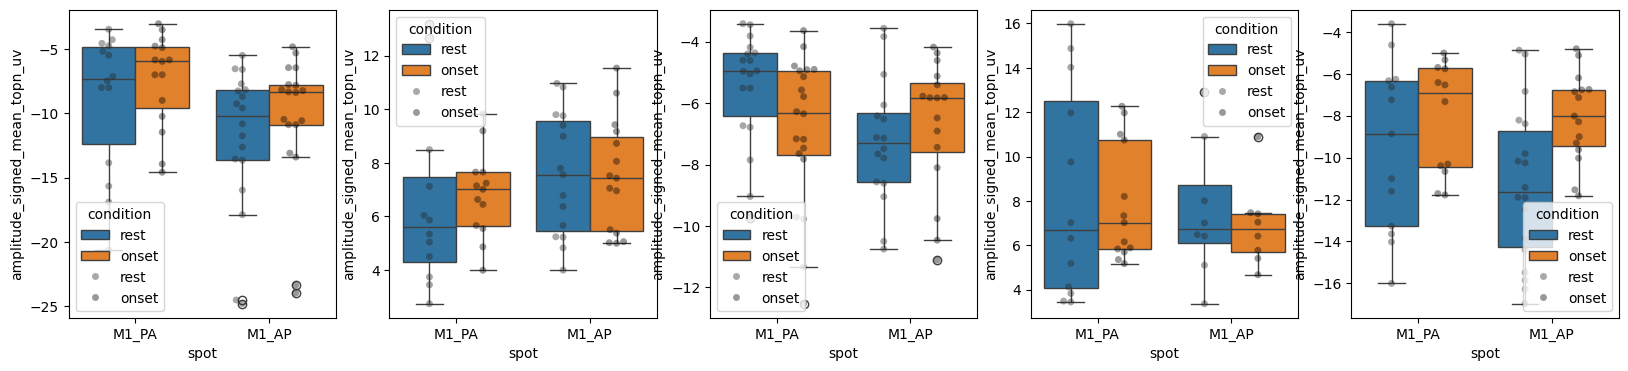

In [37]:
amp = "amplitude_signed_mean_topn_uv"
comp_names = ["n20", "p30", "n45", "p60", "n100"]
fig, ax = plt.subplots(1, len(comp_names), figsize=(20, 4))
for i, comp in enumerate(comp_names):
    sns.boxplot(df.loc[df.component == comp], y=amp, x="spot", hue="condition", ax=ax[i])
    sns.swarmplot(df.loc[df.component == comp], y=amp, x="spot", hue="condition", ax=ax[i], dodge=True, palette='dark:black', alpha=.4)

C:\Users\hodor\AppData\Local\Temp\ipykernel_17776\3347882062.py:123: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([condition_labels.get(cond, cond) for cond in conditions], fontsize=11)
C:\Users\hodor\AppData\Local\Temp\ipykernel_17776\3347882062.py:123: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([condition_labels.get(cond, cond) for cond in conditions], fontsize=11)
C:\Users\hodor\AppData\Local\Temp\ipykernel_17776\3347882062.py:123: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([condition_labels.get(cond, cond) for cond in conditions], fontsize=11)
C:\Users\hodor\AppData\Local\Temp\ipykernel_17776\3347882062.py:123: UserWarning: set_ticklabels() should only be used with a fixe

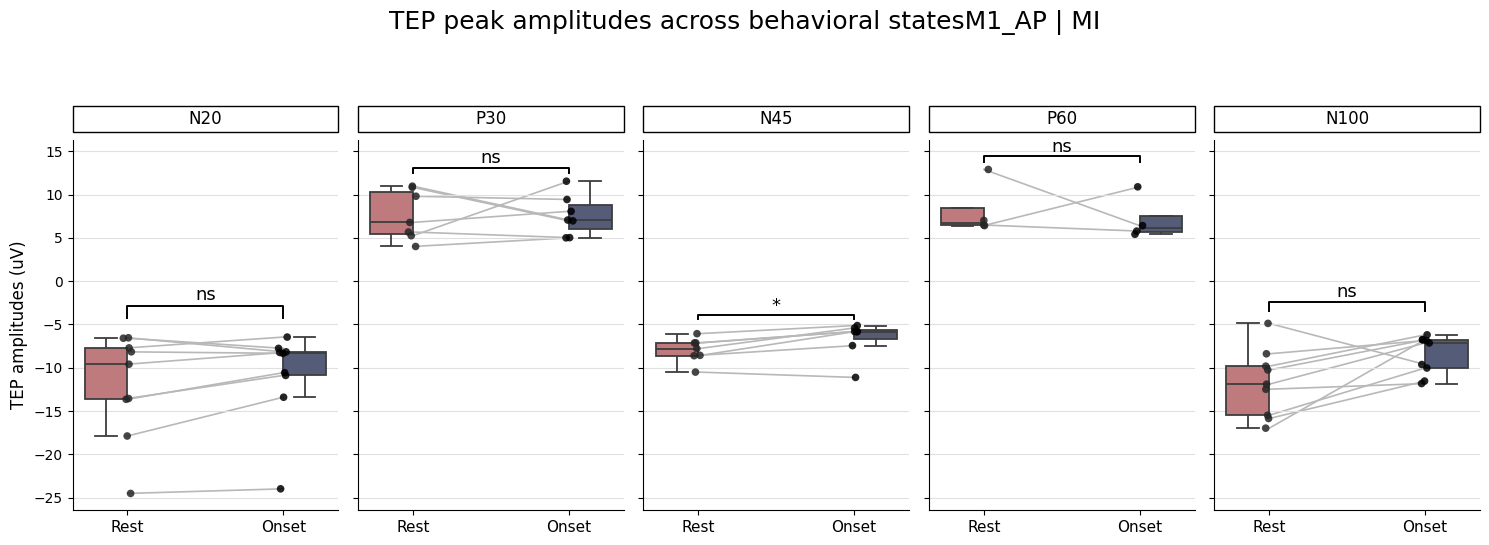

In [47]:
from scipy.stats import wilcoxon
from matplotlib.patches import Rectangle

amp = "amplitude_signed_mean_topn_uv"
# amp = "latency_mean_topn_ms"
component_order = ["n20", "p30", "n45", "p60", "n100"]
condition_order = ["rest", "onset"]
condition_labels = {"rest": "Rest", "onset": "Onset"}
palette = {"rest": "#c96f73", "onset": "#4f587d"}

# ????????? ??????? ??? ?????? ???????/???????. None ??????? ??? ????????.
spot_filter = "M1_AP"
run_cond_filter = "real"


def p_to_stars(p):
    if not np.isfinite(p):
        return "n/a"
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "ns"


def add_sig_bar(ax, x1, x2, y, text, height):
    ax.plot([x1, x1, x2, x2], [y, y + height, y + height, y], color="black", lw=1.4, clip_on=False)
    ax.text((x1 + x2) / 2, y + height * 1.15, text, ha="center", va="bottom", fontsize=13)


def plot_paired_peak_amplitudes(
    data,
    amp_col=amp,
    components=component_order,
    conditions=condition_order,
    subject_col="subject",
    pair_cols=("subject",),
    spot=None,
    run_cond=None,
    title="TEP peak amplitudes across behavioral states",
):
    plot_df = data.copy()
    plot_df = plot_df.loc[plot_df["condition"].isin(conditions) & plot_df["component"].isin(components)]

    if spot is not None and "spot" in plot_df.columns:
        plot_df = plot_df.loc[plot_df["spot"].eq(spot)]
    if run_cond is not None and "run_cond" in plot_df.columns:
        plot_df = plot_df.loc[plot_df["run_cond"].eq(run_cond)]

    plot_df = plot_df.dropna(subset=[amp_col])
    plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=conditions, ordered=True)
    plot_df["component"] = pd.Categorical(plot_df["component"], categories=components, ordered=True)

    pair_cols = [col for col in pair_cols if col in plot_df.columns]
    if not pair_cols and subject_col in plot_df.columns:
        pair_cols = [subject_col]
    if not pair_cols:
        pair_cols = ["__pair_id"]
        plot_df["__pair_id"] = plot_df.groupby(["component", "condition"]).cumcount()

    fig, axes = plt.subplots(1, len(components), figsize=(3.0 * len(components), 5), sharey=True)
    if len(components) == 1:
        axes = [axes]

    for ax, component in zip(axes, components):
        comp_df = plot_df.loc[plot_df["component"].eq(component)].copy()
        if comp_df.empty:
            ax.set_visible(False)
            continue

        sns.boxplot(
            data=comp_df,
            x="condition",
            y=amp_col,
            hue="condition",
            order=conditions,
            palette=palette,
            width=0.55,
            fliersize=0,
            linewidth=1.3,
            ax=ax,
        )
        sns.stripplot(
            data=comp_df,
            x="condition",
            y=amp_col,
            hue="condition",
            order=conditions,
            palette='dark:black',
            size=5.5,
            jitter=0.03,
            alpha=0.85,
            edgecolor="none",
            ax=ax,
        )

        wide = comp_df.pivot_table(index=pair_cols, columns="condition", values=amp_col, aggfunc="mean")
        wide = wide.dropna(subset=list(conditions))
        for _, row in wide.iterrows():
            ax.plot([0, 1], [row[conditions[0]], row[conditions[1]]], color="0.72", lw=1.2, zorder=0)

        if len(wide) > 1:
            try:
                _, p_value = wilcoxon(wide[conditions[0]], wide[conditions[1]])
            except ValueError:
                p_value = np.nan
        else:
            p_value = np.nan

        y_min = comp_df[amp_col].min()
        y_max = comp_df[amp_col].max()
        y_range = max(y_max - y_min, 1)
        add_sig_bar(ax, 0, 1, y_max + y_range * 0.12, p_to_stars(p_value), y_range * 0.08)

        ax.add_patch(Rectangle((0, 1.02), 1, 0.07, transform=ax.transAxes, fill=False, clip_on=False, lw=1.0))
        ax.text(0.5, 1.055, component.upper(), transform=ax.transAxes, ha="center", va="center", fontsize=12)

        ax.set_xlabel("")
        ax.set_xticklabels([condition_labels.get(cond, cond) for cond in conditions], fontsize=11)
        ax.grid(axis="y", color="0.88", linewidth=0.8)
        ax.grid(axis="x", visible=False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        if ax is not axes[0]:
            ax.set_ylabel("")
        else:
            ax.set_ylabel("TEP amplitudes (uV)", fontsize=12)

    subtitle = []
    if spot is not None:
        subtitle.append(str(spot))
    if run_cond is not None:
        subtitle.append(str(run_cond))
    full_title = title if not subtitle else f"{title}{' | '.join(subtitle)}"
    fig.suptitle(full_title, fontsize=18, y=1.08)
    fig.tight_layout()
    return fig, axes

# ????????? ??????? ??? ?????? ???????/???????. None ??????? ??? ????????.
spot_filter = "M1_AP"
run_cond_filter = "MI" # "real"

import numpy as np
fig, axes = plot_paired_peak_amplitudes(
    df,
    spot=spot_filter,
    run_cond=run_cond_filter,
    pair_cols=("subject",),
)


C:\Users\hodor\AppData\Local\Temp\ipykernel_17776\3347882062.py:123: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([condition_labels.get(cond, cond) for cond in conditions], fontsize=11)
C:\Users\hodor\AppData\Local\Temp\ipykernel_17776\3347882062.py:123: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([condition_labels.get(cond, cond) for cond in conditions], fontsize=11)
C:\Users\hodor\AppData\Local\Temp\ipykernel_17776\3347882062.py:123: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([condition_labels.get(cond, cond) for cond in conditions], fontsize=11)
C:\Users\hodor\AppData\Local\Temp\ipykernel_17776\3347882062.py:123: UserWarning: set_ticklabels() should only be used with a fixe

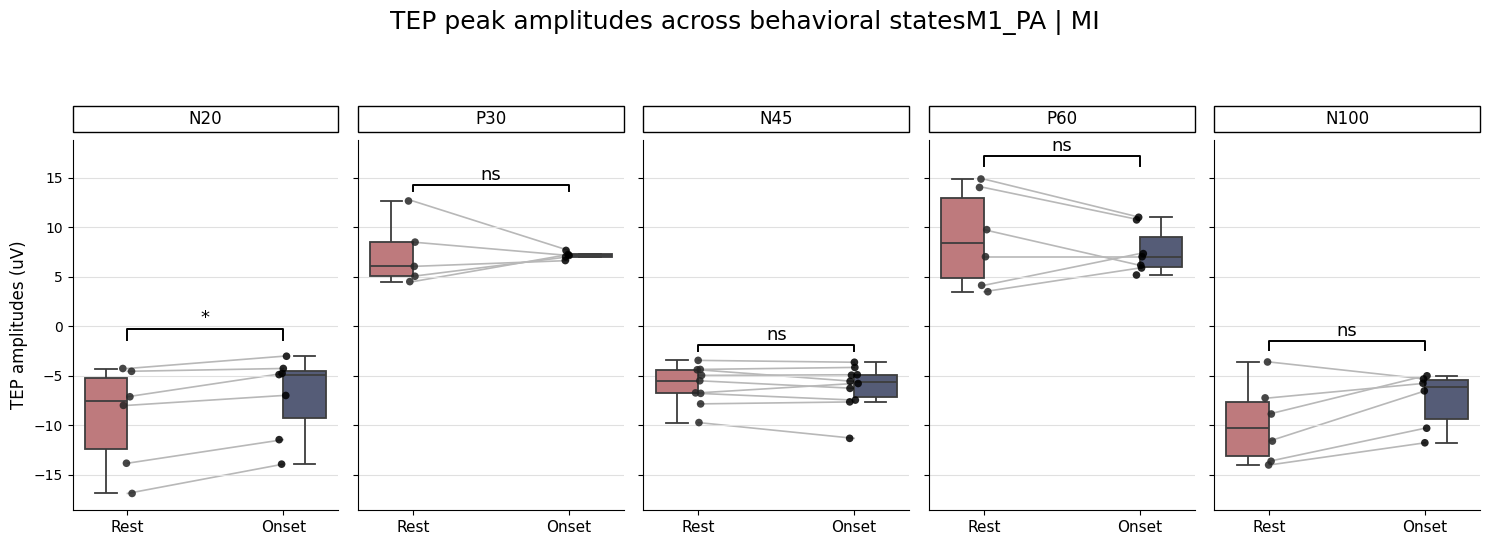

In [48]:
# ????????? ??????? ??? ?????? ???????/???????. None ??????? ??? ????????.
spot_filter = "M1_PA"
run_cond_filter =  "MI" # "real"

import numpy as np
fig, axes = plot_paired_peak_amplitudes(
    df,
    spot=spot_filter,
    run_cond=run_cond_filter,
    pair_cols=("subject",),
)

<Axes: xlabel='run_cond', ylabel='amplitude_signed_mean_topn_uv'>

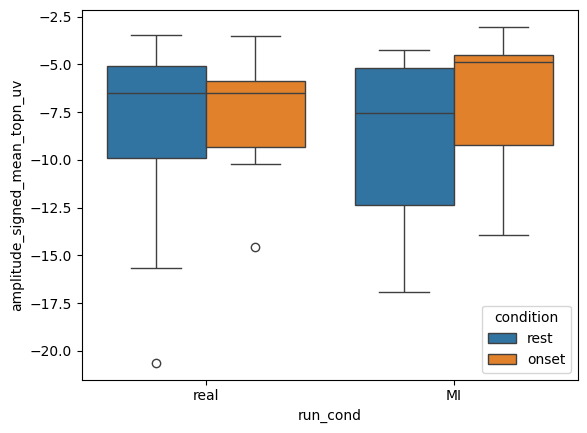

In [62]:
comp = "n20"
spot = "M1_PA"
df_comp = df.loc[(df.component == "n20") & (df.spot == spot)]
sns.boxplot(df_comp, x="run_cond", y=amp, hue="condition")

In [59]:
df

,subject,session,run_cond,spot,condition,component,window_start_ms,window_end_ms,amplitude_abs_mean_topn_uv,amplitude_signed_mean_topn_uv,latency_mean_topn_ms,peak_amplitude_uv,peak_latency_ms,peak_channel_idx,n_selected,peak_channel,source_files,source_originals
0,01AV,38,real,M1_PA,rest,n20,10.0,25.0,20.622184,-20.622184,21.000000,-23.306814,21.8,38,3,CP3,session_38__set_1__cleaned_SOUND.mat; session_...,01_01AV_M1_PA_39MSO_real.hdf5; 05_01AV_M1_PA_3...
1,01AV,38,real,M1_PA,rest,p30,20.0,40.0,NaN,NaN,NaN,NaN,NaN,15,3,Fp2,session_38__set_1__cleaned_SOUND.mat; session_...,01_01AV_M1_PA_39MSO_real.hdf5; 05_01AV_M1_PA_3...
2,01AV,38,real,M1_PA,rest,n45,40.0,55.0,NaN,NaN,NaN,NaN,NaN,62,3,FT8,session_38__set_1__cleaned_SOUND.mat; session_...,01_01AV_M1_PA_39MSO_real.hdf5; 05_01AV_M1_PA_3...
3,01AV,38,real,M1_PA,rest,p60,55.0,70.0,15.985824,15.985824,61.800000,18.095181,62.6,9,3,C3,session_38__set_1__cleaned_SOUND.mat; session_...,01_01AV_M1_PA_39MSO_real.hdf5; 05_01AV_M1_PA_3...
4,01AV,38,real,M1_PA,rest,n100,80.0,120.0,16.000822,-16.000822,106.133333,-17.534327,106.2,38,3,CP3,session_38__set_1__cleaned_SOUND.mat; session_...,01_01AV_M1_PA_39MSO_real.hdf5; 05_01AV_M1_PA_3...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,14AL,58,MI,M1_AP,onset,n20,10.0,25.0,10.884502,-10.884502,10.600000,-12.903188,10.6,42,3,C1,session_58__set_2__cleaned_SOUND.mat; session_...,01_14AL_M1_AP_54MSO_MI.hdf5; 05_14AL_M1_AP_54M...
651,14AL,58,MI,M1_AP,onset,p30,20.0,40.0,6.958537,6.958537,21.666667,7.263852,22.2,12,3,Fp1,session_58__set_2__cleaned_SOUND.mat; session_...,01_14AL_M1_AP_54MSO_MI.hdf5; 05_14AL_M1_AP_54M...
652,14AL,58,MI,M1_AP,onset,n45,40.0,55.0,5.408608,-5.408608,46.466667,-6.038879,40.4,11,3,O1,session_58__set_2__cleaned_SOUND.mat; session_...,01_14AL_M1_AP_54MSO_MI.hdf5; 05_14AL_M1_AP_54M...
653,14AL,58,MI,M1_AP,onset,p60,55.0,70.0,6.409894,6.409894,64.800000,6.771392,63.0,47,3,Fpz,session_58__set_2__cleaned_SOUND.mat; session_...,01_14AL_M1_AP_54MSO_MI.hdf5; 05_14AL_M1_AP_54M...


In [55]:
df_comp

,subject,session,run_cond,spot,condition,component,window_start_ms,window_end_ms,amplitude_abs_mean_topn_uv,amplitude_signed_mean_topn_uv,latency_mean_topn_ms,peak_amplitude_uv,peak_latency_ms,peak_channel_idx,n_selected,peak_channel,source_files,source_originals
0,01AV,38,real,M1_PA,rest,n20,10.0,25.0,20.622184,-20.622184,21.000000,-23.306814,21.8,38,3,CP3,session_38__set_1__cleaned_SOUND.mat; session_...,01_01AV_M1_PA_39MSO_real.hdf5; 05_01AV_M1_PA_3...
5,01AV,38,real,M1_PA,onset,n20,10.0,25.0,10.235959,-10.235959,18.266667,-11.611969,18.2,38,3,CP3,session_38__set_1__cleaned_SOUND.mat; session_...,01_01AV_M1_PA_39MSO_real.hdf5; 05_01AV_M1_PA_3...
15,01AV,38,real,M1_AP,rest,n20,10.0,25.0,9.256587,-9.256587,19.400000,-10.140285,20.4,38,3,CP3,session_38__set_3__cleaned_SOUND.mat; session_...,03_01AV_M1_AP_43MSO_real.h5; 07_01AV_M1_AP_43M...
20,01AV,38,real,M1_AP,onset,n20,10.0,25.0,4.827488,-4.827488,15.800000,-5.579812,18.4,9,3,C3,session_38__set_3__cleaned_SOUND.mat; session_...,03_01AV_M1_AP_43MSO_real.h5; 07_01AV_M1_AP_43M...
45,01AV,38,MI,M1_PA,rest,n20,10.0,25.0,16.897274,-16.897274,20.866667,-19.479976,20.4,38,3,CP3,session_38__set_2__cleaned_SOUND.mat; session_...,02_01AV_M1_PA_39MSO_MI.hdf5; 06_01AV_M1_PA_39M...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,14AL,58,real,M1_AP,onset,n20,10.0,25.0,10.880699,-10.880699,10.666667,-12.586365,10.8,42,3,C1,session_58__set_1__cleaned_SOUND.mat; session_...,00_14AL_M1_AP_54MSO_real.hdf5; 04_14AL_M1_AP_5...
630,14AL,58,MI,M1_PA,rest,n20,10.0,25.0,13.845354,-13.845354,13.866667,-16.878834,13.8,54,3,PO8,session_58__set_4__cleaned_SOUND.mat; session_...,03_14AL_M1_PA_41MSO_MI.hdf5; 07_14AL_M1_PA_41M...
635,14AL,58,MI,M1_PA,onset,n20,10.0,25.0,11.463867,-11.463867,12.000000,-12.249905,11.0,9,3,C3,session_58__set_4__cleaned_SOUND.mat; session_...,03_14AL_M1_PA_41MSO_MI.hdf5; 07_14AL_M1_PA_41M...
645,14AL,58,MI,M1_AP,rest,n20,10.0,25.0,13.546447,-13.546447,12.533333,-14.558914,12.0,42,3,C1,session_58__set_2__cleaned_SOUND.mat; session_...,01_14AL_M1_AP_54MSO_MI.hdf5; 05_14AL_M1_AP_54M...


In [7]:
subjects = df_all["subject"].unique()
subjects

<StringArray>
['01AV', '04KK', '02NS', '03AZ', '07IK', '05UB', '08EN', '10ES']
Length: 8, dtype: str

In [21]:
def get_power(name):
    return name[name.find("MSO")-2:name.find("MSO")]

df_powers = []
for subject in subjects:
    for spot in ['M1_PA', 'M1_AP']:
        curr_df = df_all.loc[(df_all.subject == subject) & (df_all.spot == spot)]
        if len(curr_df) != 0:
            name = curr_df.iloc[0]["source_originals"]
            power = get_power(name)
            df_powers.append({
                'subject': subject, 
                "direction": spot, 
                "power": power
            })
df_powers = pd.DataFrame(df_powers)
df_powers["RMT"] = 
df_powers

,subject,direction,power
0,01AV,M1_PA,39
1,01AV,M1_AP,43
2,04KK,M1_PA,32
3,04KK,M1_AP,50
4,02NS,M1_PA,52
5,02NS,M1_AP,60
6,03AZ,M1_PA,35
7,07IK,M1_PA,38
8,07IK,M1_AP,52
9,05UB,M1_PA,25


In [12]:
subject

'03AZ'